从这个来看，企业肯定是鼓励大batch size的

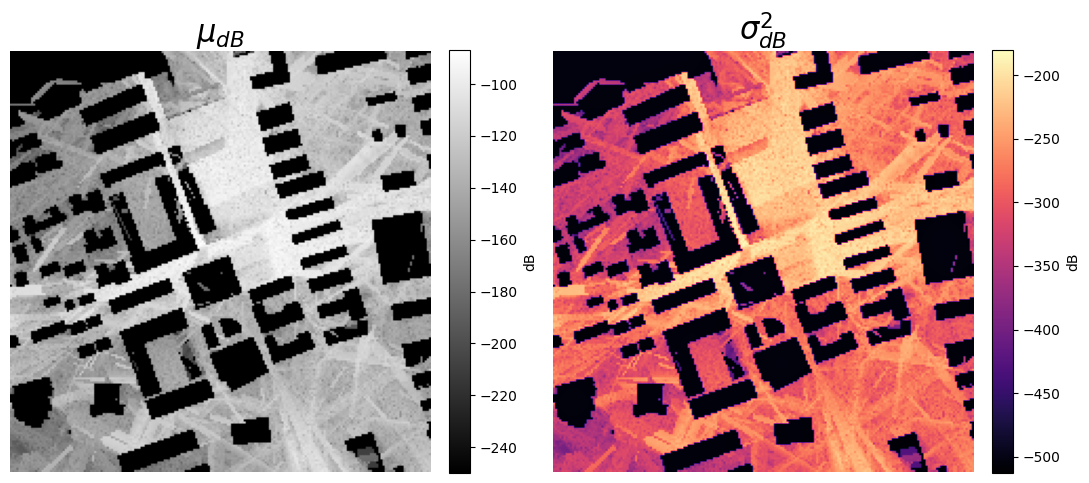

In [ ]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Optional, Tuple
import numpy as np


@dataclass
class RealCKM:
    """
    CKM backed by a real channel gain map.

    gain_map stores mu_dB(q) in dB, with values typically in [-250, -50].
    Building pixels are assumed to be mapped to the minimum value (or below
    a chosen threshold), and local building ratio is used to determine the
    fluctuation strength through CV^2(q) = sigma^2(q) / mu(q)^2.
    """
    gain_map: np.ndarray                              # shape [H, W], values in dB
    xlim: Tuple[float, float] = (0.0, 400.0)
    ylim: Tuple[float, float] = (0.0, 400.0)

    # building / valid-region control
    building_db_threshold: float = -249.0            # <= threshold treated as building
    sample_only_non_building: bool = True

    # local neighborhood for complexity estimation
    window_size: int = 21

    # CV^2(q) = sigma^2(q) / mu(q)^2
    cv2_min: float = 0.05
    cv2_max: float = 0.50

    # numerical floor for mu in linear scale
    mu_floor_linear: float = 1e-30

    # cached masks / maps
    building_mask: np.ndarray = field(init=False)
    valid_mask: np.ndarray = field(init=False)
    cv2_map: np.ndarray = field(init=False)

    def __post_init__(self) -> None:
        self.gain_map = np.asarray(self.gain_map, dtype=np.float64)
        if self.gain_map.ndim != 2:
            raise ValueError("gain_map must be a 2D array.")

        self.H, self.W = self.gain_map.shape

        self.building_mask = self.gain_map <= self.building_db_threshold
        self.valid_mask = ~self.building_mask

        if self.sample_only_non_building and not np.any(self.valid_mask):
            raise ValueError("No valid non-building pixels available for user sampling.")

        self.cv2_map = self._build_cv2_map()

    # ------------------------------------------------------------
    # coordinate conversion
    # ------------------------------------------------------------
    def _xy_to_rc(self, q: Tuple[float, float]) -> Tuple[int, int]:
        """
        Map physical coordinate q=(x,y) to image index (row, col).

        Assumption:
          - x increases from left to right
          - y increases from bottom to top in physical coordinates
          - image row index increases from top to bottom
        """
        x, y = q
        x0, x1 = self.xlim
        y0, y1 = self.ylim

        x_norm = (x - x0) / max(x1 - x0, 1e-12)
        y_norm = (y - y0) / max(y1 - y0, 1e-12)

        x_norm = float(np.clip(x_norm, 0.0, 1.0))
        y_norm = float(np.clip(y_norm, 0.0, 1.0))

        col = int(round(x_norm * (self.W - 1)))
        row = int(round((1.0 - y_norm) * (self.H - 1)))  # flip y-axis

        row = int(np.clip(row, 0, self.H - 1))
        col = int(np.clip(col, 0, self.W - 1))
        return row, col

    def _rc_to_xy(self, row: int, col: int) -> Tuple[float, float]:
        x0, x1 = self.xlim
        y0, y1 = self.ylim

        x = x0 + (col / max(self.W - 1, 1)) * (x1 - x0)
        y = y0 + (1.0 - row / max(self.H - 1, 1)) * (y1 - y0)
        return float(x), float(y)

    # ------------------------------------------------------------
    # local complexity -> CV^2 map
    # ------------------------------------------------------------
    def _build_cv2_map(self) -> np.ndarray:
        """
        Build CV^2(q) map based on local building ratio.
        """
        pad = self.window_size // 2
        bld = self.building_mask.astype(np.float64)
        padded = np.pad(bld, ((pad, pad), (pad, pad)), mode="edge")

        cv2_map = np.zeros_like(self.gain_map, dtype=np.float64)

        for r in range(self.H):
            for c in range(self.W):
                local_ratio = np.sum(
                    padded[r:r + 2 * pad + 1, c:c + 2 * pad + 1]
                ) / ((2 * pad + 1) ** 2)
                cv2_map[r, c] = self.cv2_min + (self.cv2_max - self.cv2_min) * local_ratio
        return cv2_map

    # ------------------------------------------------------------
    # public API
    # ------------------------------------------------------------
    def lookup(self, q: Tuple[float, float]) -> Tuple[float, float]:
        """
        Return (mu, sigma2) in linear scale.
        """
        row, col = self._xy_to_rc(q)

        mu_db = float(self.gain_map[row, col])
        mu = 10.0 ** (mu_db / 10.0)
        mu = max(mu, self.mu_floor_linear)

        cv2 = float(self.cv2_map[row, col])
        sigma2 = cv2 * (mu ** 2)
        return float(mu), float(sigma2)

    def sample_user(self, rng: np.random.Generator) -> Tuple[Tuple[float, float], float, float]:
        """
        Sample a user location and return (q, mu, sigma2).
        """
        if self.sample_only_non_building:
            valid_indices = np.argwhere(self.valid_mask)
            idx = int(rng.integers(0, len(valid_indices)))
            row, col = valid_indices[idx]
            q = self._rc_to_xy(int(row), int(col))
        else:
            row = int(rng.integers(0, self.H))
            col = int(rng.integers(0, self.W))
            q = self._rc_to_xy(row, col)

        mu, sigma2 = self.lookup(q)
        return q, mu, sigma2
    
    def visualize_maps(self) -> None:
        """
        Visualize gain_map, cv2_map, and sigma2_map.
        - gain_map: mu_dB(q), in dB
        - cv2_map: CV^2(q) = sigma^2(q) / mu(q)^2
        - sigma2_map: variance in linear scale; displayed in log10 domain
        because its dynamic range is usually very large
        """
        import matplotlib.pyplot as plt
        import numpy as np

        gain_map = self.gain_map.astype(np.float64)
        cv2_map = self.cv2_map.astype(np.float64)

        mu_map = 10.0 ** (gain_map / 10.0)
        mu_map = np.maximum(mu_map, self.mu_floor_linear)
        sigma2_map = cv2_map * (mu_map ** 2)

        sigma2_map_dB = 10 * np.log10(np.maximum(sigma2_map, 1e-300))

        fig, axes = plt.subplots(1, 2, figsize=(11, 5))

        im0 = axes[0].imshow(gain_map, cmap="gray", vmin=np.min(gain_map), vmax=np.max(gain_map))
        axes[0].set_title("$\mu_{dB}$", fontsize=22, fontweight='bold')
        axes[0].axis("off")
        cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
        cbar0.set_label("dB", fontsize=16, fontweight='bold')
        cbar0.ax.tick_params(labelsize=14)
        for label in cbar0.ax.get_yticklabels():
            label.set_fontweight('bold')

        # im1 = axes[1].imshow(cv2_map, cmap="viridis", vmin=self.cv2_min, vmax=self.cv2_max)
        # axes[1].set_title("cv2_map")
        # axes[1].axis("off")
        # plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="CV^2")

        # im2 = axes[2].imshow(sigma2_map_dB, cmap="magma")
        # axes[2].set_title("$\sigma^{2}_{dB}$")
        # axes[2].axis("off")
        # plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="dB")
        
        im1 = axes[1].imshow(sigma2_map_dB, cmap="magma")
        axes[1].set_title("$\sigma^{2}_{dB}$", fontsize=22, fontweight='bold')
        axes[1].axis("off")
        cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        cbar1.set_label("dB", fontsize=16, fontweight='bold')
        cbar1.ax.tick_params(labelsize=14)
        for label in cbar1.ax.get_yticklabels():
            label.set_fontweight('bold')

        plt.tight_layout()
        fig.savefig("D:/contollable transmission/fig/CKM.pdf", bbox_inches="tight")
        plt.show()
    
    
data = np.load('./gain.npz')
gain_map = data['arr_0']

ckm = RealCKM(
    gain_map=gain_map,
    xlim=(0.0, 400.0),
    ylim=(0.0, 400.0),
    building_db_threshold=-249.0,
    sample_only_non_building=True,
    window_size=20,
    cv2_min=0.05,
    cv2_max=0.50,
    mu_floor_linear=1e-30,
)

ckm.visualize_maps()

In [51]:
import numpy as np

# 读取 CKM
data = np.load('./gain.npz')
gain_map = data['arr_0']   # shape: (H, W)

# 1) 取非建筑区域
# 按你的设定：建筑区域都映射为 0
non_building = gain_map[gain_map >= -249]

total_non_building = non_building.size
print(f"非建筑区域总位置数: {total_non_building}")

# 2) 定义区间
# 例如：(-inf, -150), [-150, -140), [-140, -130), ...
bins = [-np.inf, -150, -149, -147.5, -146, -145, -144, -143, -142, -141, -140, -139, -137, -136, -133, np.inf]

# 3) 统计每个区间的位置数
counts, edges = np.histogram(non_building, bins=bins)

# 4) 计算占比
ratios = counts / total_non_building

# 5) 打印结果
for i in range(len(counts)):
    left = edges[i]
    right = edges[i + 1]
    cnt = counts[i]
    ratio = ratios[i]

    if np.isneginf(left):
        label = f"< {right:.0f} dB"
    elif np.isposinf(right):
        label = f">= {left:.0f} dB"
    else:
        label = f"[{left:.0f}, {right:.0f}) dB"

    print(f"{label:15s} : {cnt:8d}  ({ratio:.4%})")

非建筑区域总位置数: 27973
< -150 dB       :     6165  (22.0391%)
[-150, -149) dB :      372  (1.3299%)
[-149, -148) dB :      578  (2.0663%)
[-148, -146) dB :      635  (2.2700%)
[-146, -145) dB :      404  (1.4442%)
[-145, -144) dB :      455  (1.6266%)
[-144, -143) dB :      425  (1.5193%)
[-143, -142) dB :      444  (1.5872%)
[-142, -141) dB :      487  (1.7410%)
[-141, -140) dB :      472  (1.6873%)
[-140, -139) dB :      453  (1.6194%)
[-139, -137) dB :      970  (3.4676%)
[-137, -136) dB :      483  (1.7267%)
[-136, -133) dB :     1556  (5.5625%)
>= -133 dB      :    14074  (50.3128%)


计算模型

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Simulation parameters
# =========================
import math

R = 10*1e6  # 10Mb/s
Bw = 10*1e6  # 10MHz
N0 = 3.98*1e-18
p_max = 0.4  # W
channel_power_gain = -147
additional_gain = 33
g = 10**((channel_power_gain+additional_gain)/10.0)
uplink_times = 30

gamma_acc_1 = p_max * g / (N0 * Bw)
gamma_acc = gamma_acc_1 * uplink_times
C = Bw * math.log2(1.0 + gamma_acc)
print(f"信道功率增益{channel_power_gain}dB，额外增益（波束赋形、阵列）{additional_gain}dB")
print(f"以p_max={p_max}W传输{uplink_times}次的等效信道容量为{(C/1e6):.1f} Million bit/s")
print(f"上行传输速率为{R/1e6} Million bit/s")

N_token = 256
L = 32*N_token  # ，一个token 32个bit
print(f"一个prompt {N_token} 个 token，对应{L}个bit，单次上传时间为{L/R}秒，传输{uplink_times}次的时长为{(uplink_times*L/R*1000):.1f}毫秒")

信道功率增益-147dB，额外增益（波束赋形、阵列）33dB
以p_max=0.4W传输30次的等效信道容量为11.4 Million bit/s
上行传输速率为10.0 Million bit/s
一个prompt 256 个 token，对应8192个bit，单次上传时间为0.0008192秒，传输30次的时长为24.6毫秒


In [53]:
Tul_pp = (13.1*0.15 + 1.6*0.17 + 0.8*0.45)/0.8
print(f"单上行资源块单prompt平均上传时长{Tul_pp}毫秒")

单上行资源块单prompt平均上传时长3.24625毫秒


In [54]:
# Prefill latency model: tau_pf(B, L) = beta0 + beta1 * B * L + beta2 * B * L^2
beta0 = 8.0 * 1e-3         # s
beta1 = 10 * 1e-6         # s/token  这一项在prompt的token数比较小的时候有影响
beta2 = 9 * 1e-9         # s/token^2

# GPU power model:
# P_pf(B) = Pmin + DeltaPmax / (1 + exp(-k1 * (log2(B) - k2)))
Pmin = 110.0         # W
DeltaPmax = 190.0    # W
k1 = 1.6
k2 = 5

# Batch size range
B = np.arange(1, 65)   # 1 ~ 64

# =========================
# 2. Model definitions
# =========================
def tau_pf(B, N_token, beta0, beta1, beta2):
    return beta0 + beta1 * B * N_token + beta2 * B * (N_token ** 2)   # s

def P_pf(B, Pmin, DeltaPmax, k1, k2):
    return Pmin + DeltaPmax / (1 + np.exp(-k1 * (np.log2(B) - k2)))  # W

latency_ms = tau_pf(B, N_token, beta0, beta1, beta2)
power_W = P_pf(B, Pmin, DeltaPmax, k1, k2)

# Optional: print gamma1 in the simplified linear model tau_pf(B)=beta0+gamma1*B
gamma1 = beta1 * N_token + beta2 * (N_token ** 2)
print(f"gamma1 = {gamma1:.4f} s")
print(f"Equivalent latency model: tau_pf(B) ≈ {beta0:.2f} + {gamma1:.4f} * B (s)")


gamma1 = 0.0031 s
Equivalent latency model: tau_pf(B) ≈ 0.01 + 0.0031 * B (s)


In [55]:
# 到达强度lambda的极限值
K = 4  # 上行资源块数
N = K  # 假设GPU数和上行资源块数相同
_lambda = N/gamma1  # gamma1视为T_pf/B
print(_lambda)

1269.9122236671


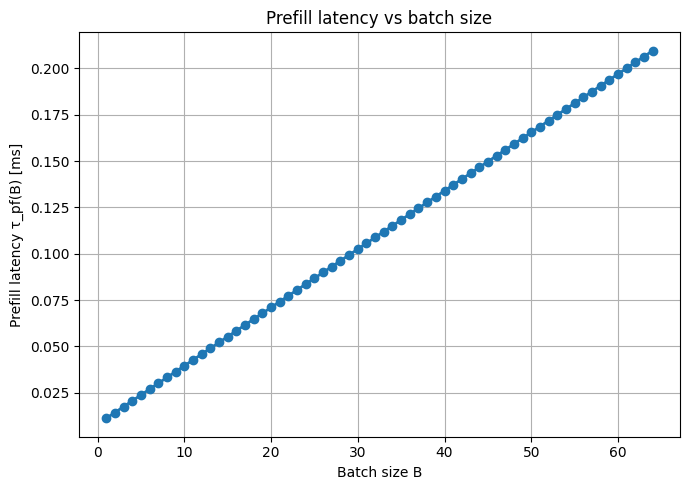

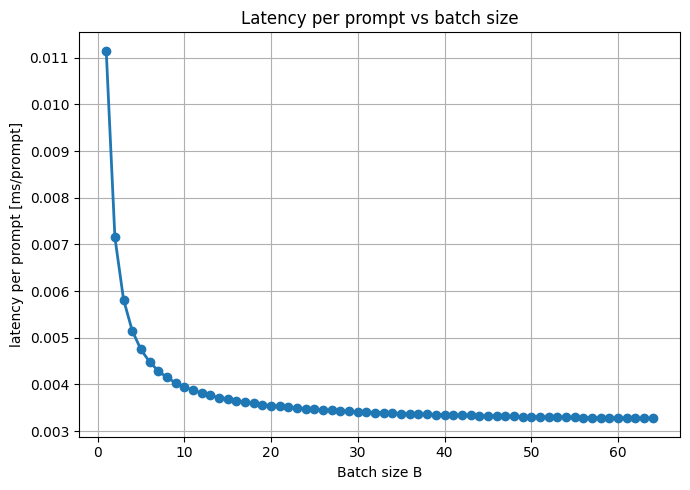

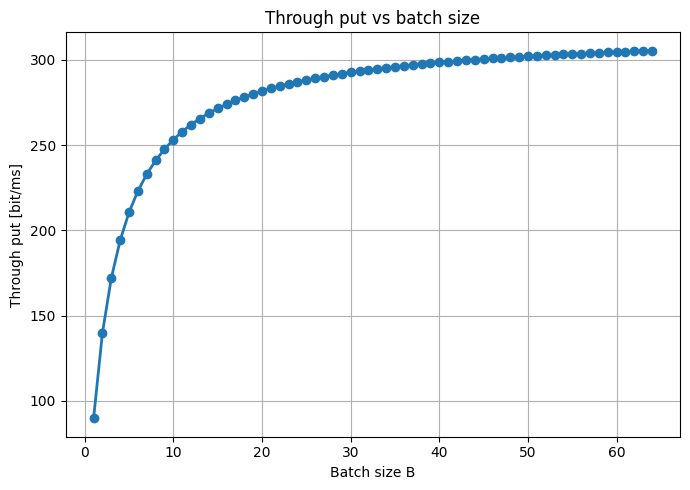

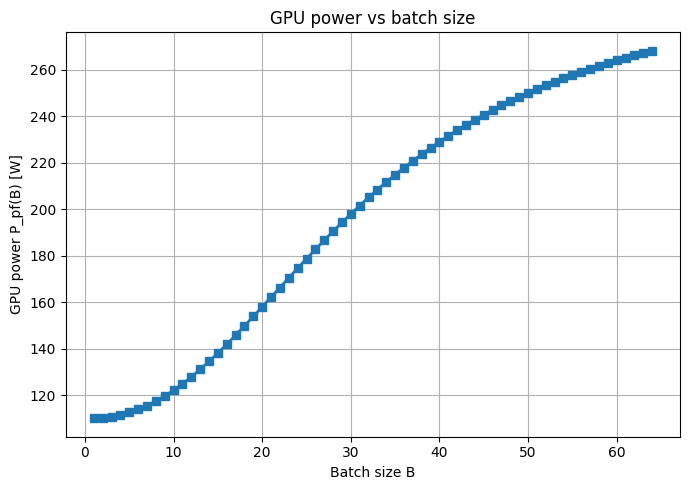

In [56]:
# =========================
# 3. Plot latency vs batch size
# =========================
plt.figure(figsize=(7, 5))
plt.plot(B, latency_ms, marker='o', linewidth=2)
plt.xlabel("Batch size B")
plt.ylabel("Prefill latency τ_pf(B) [ms]")
plt.title("Prefill latency vs batch size")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 4. Plot latency per prompt vs batch size
# =========================
plt.figure(figsize=(7, 5))
plt.plot(B, latency_ms/B, marker='o', linewidth=2)
plt.xlabel("Batch size B")
plt.ylabel("latency per prompt [ms/prompt]")
plt.title("Latency per prompt vs batch size")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 5. Throught put vs batch size
# =========================
plt.figure(figsize=(7, 5))
plt.plot(B, B/latency_ms, marker='o', linewidth=2)
plt.xlabel("Batch size B")
plt.ylabel("Through put [bit/ms]")
plt.title("Through put vs batch size")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 6. Plot power vs batch size
# =========================
plt.figure(figsize=(7, 5))
plt.plot(B, power_W, marker='s', linewidth=2)
plt.xlabel("Batch size B")
plt.ylabel("GPU power P_pf(B) [W]")
plt.title("GPU power vs batch size")
plt.grid(True)
plt.tight_layout()
plt.show()

## tail 图

| 功率增益 g_dB | -150 | -149 |-148|-146 | -145 | -144 | -143 | -142 | -141 | -140 | -139 | -137 | -136 | -133 |
| --------- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |---: |
| 传输次数 m|50 | 40 |30 | 20 |   17   |   13 |   10 |    8 |    7 |    5 |    4 |    3 |    2 |    1 |
| 位置数    |  372 | 578 | 635 |404 |   455 |   425 |    444 |    487 | 472 | 453 |    970 |    483 |  1556 | 14074 |

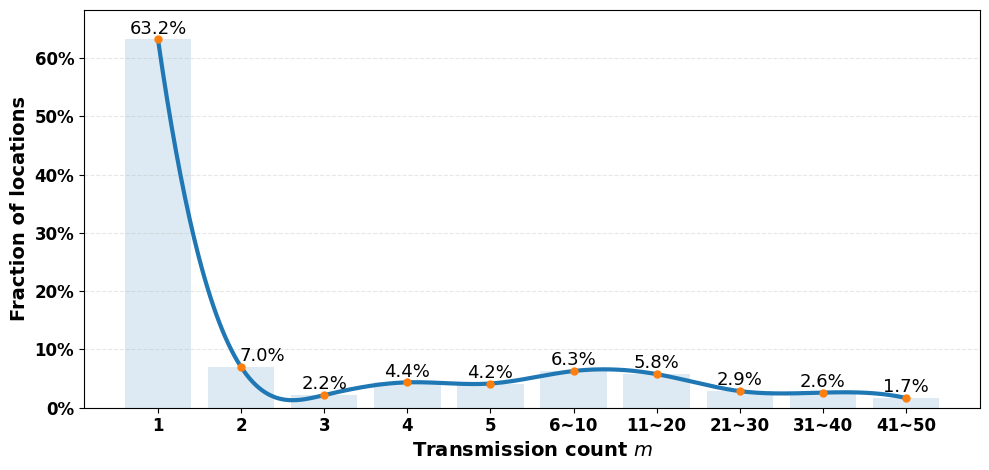

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from matplotlib.ticker import PercentFormatter

# 原始数据
m = np.array([50, 40, 30, 20, 17, 13, 10, 8, 7, 5, 4, 3, 2, 1])
num_positions = np.array([372, 578, 635, 404, 455, 425, 444, 487, 472, 925, 970, 483, 1556, 14074])

# 原始占比
ratio = num_positions / num_positions.sum()

# 按 m 升序排序
idx = np.argsort(m)
m_sorted = m[idx]
ratio_sorted = ratio[idx]

# 原始标签
# 依次对应：
# 1, 1~2, 2~3, 3~4, 4~5, 5~7, 7~8, 8~10, 10~13, 13~17, 17~20, 20~30, 30~40, 40~50

# 重新分组后的标签与占比
new_labels = [
    '1',
    '2',
    '3',
    '4',
    '5',
    '6~10',
    '11~20',
    '21~30',
    '31~40',
    '41~50'
]

new_ratio = np.array([
    ratio_sorted[0],                                # 1
    ratio_sorted[1],                                # 1~2 -> 2
    ratio_sorted[2],                                # 2~3 -> 3
    ratio_sorted[3],                                # 3~4 -> 4
    ratio_sorted[4],                                # 4~5 -> 5
    ratio_sorted[5] + ratio_sorted[6] + ratio_sorted[7],   # 5~7 + 7~8 + 8~10 -> 6~10
    ratio_sorted[8] + ratio_sorted[9] + ratio_sorted[10],  # 10~13 + 13~17 + 17~20 -> 11~20
    ratio_sorted[11],                               # 20~30 -> 21~30
    ratio_sorted[12],                               # 30~40 -> 31~40
    ratio_sorted[13],                               # 40~50 -> 41~50
])

# 新横坐标
x = np.arange(len(new_labels))

# 平滑插值
x_smooth = np.linspace(x.min(), x.max(), 500)
spline = make_interp_spline(x, new_ratio, k=3)
y_smooth = np.clip(spline(x_smooth), 0, None)

# 作图
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(x, new_ratio, width=0.8, alpha=0.15, label='Original distribution')
ax.plot(x_smooth, y_smooth, linewidth=3, label='Smoothed curve')
ax.scatter(x, new_ratio, s=25, zorder=3)

ax.set_xlabel('Transmission count $m$', fontsize=14, fontweight='bold')
ax.set_ylabel('Fraction of locations', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(new_labels, rotation=0, ha='center')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
# ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, max(new_ratio) * 1.08)
ax.tick_params(axis='both', labelsize=12)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
count = 0
for bar, val in zip(bars, new_ratio):
    if count == 1:
        ax.text(
            bar.get_x() + bar.get_width() / 2 + 0.25,
            bar.get_height() + 0.003,
            f'{val:.1%}',
            ha='center',
            va='bottom',
            fontsize=13
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{val:.1%}',
            ha='center',
            va='bottom',
            fontsize=13
        )  
    
    count = count + 1
    

plt.tight_layout()
fig.savefig("D:/contollable transmission/fig/transmission_distribution.pdf", bbox_inches="tight")
plt.show()